# Part 3 Step 2 — Focused + Verified compositions

**Question:** can `verified` improve the Step-1 focused leaders by re-confirming kills?


Step-1 leaders, for reference: `full_focused` 27.5 % · `half_focused` 36.2 % · `half_focused_k7` 38.3 %.

In [16]:
import json, glob, statistics
from pathlib import Path
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

# Walk up from cwd to the repo root (where 'results/' and 'data/' live).
# Robust to Jupyter being launched from the notebook dir or the repo root.
ROOT = Path.cwd().resolve()
while not ((ROOT / 'results').is_dir() and (ROOT / 'data').is_dir()):
    if ROOT == ROOT.parent:
        raise RuntimeError(f"can't find repo root from {Path.cwd()}")
    ROOT = ROOT.parent
RUNS = ROOT / 'results' / 'crosswords' / 'runs'
assert RUNS.is_dir()

# ---------------- Report palette ----------------
CHARCOAL = '#233d4d'
PUMPKIN  = '#fe7f2d'
GOLDEN   = '#fcca46'
OLIVE    = '#a1c181'
SEAGRASS = '#619b8a'

mpl.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'white',
    'axes.edgecolor':CHARCOAL,'axes.labelcolor':CHARCOAL,'axes.titlecolor':CHARCOAL,
    'axes.titleweight':'bold','axes.labelweight':'bold',
    'axes.titlesize':14,'axes.labelsize':12,'axes.linewidth':1.6,
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':False,
    'xtick.color':CHARCOAL,'ytick.color':CHARCOAL,
    'xtick.labelsize':11,'ytick.labelsize':11,
    'xtick.major.size':0,'ytick.major.size':4,
    'font.weight':'bold','font.family':'sans-serif',
    'legend.frameon':False,'legend.fontsize':11,
    'lines.linewidth':2.6,'lines.markersize':9,
    'savefig.dpi':180,'savefig.bbox':'tight',
})

## 1. Helpers

In [17]:
def grid_metrics(grid, gt):
    flat = [c.upper() for r in grid for c in r]
    truth = [c.upper() for c in gt]
    if len(flat) != 25: return 0.0, 0.0, 0.0
    cl = sum(1 for o, t in zip(flat, truth) if o == t)
    cw = sum(1 for i in range(5) if flat[i*5:(i+1)*5] == truth[i*5:(i+1)*5])
    cw += sum(1 for i in range(5) if flat[i::5] == truth[i::5])
    return cl/25, cw/10, 1.0 if cl == 25 else 0.0

def load_runs(pattern, expected_n=20):
    out = []
    for fp in sorted(glob.glob(str(RUNS/pattern))):
        with open(fp) as f:
            rows = [json.loads(line) for line in f if line.strip()]
        if len(rows) >= expected_n:
            out.append({'file': Path(fp).name, 'rows': rows})
    return out

def run_metrics(rows):
    Ls, Ws, Gs, Ss, Cs = [], [], [], [], []
    for r in rows:
        l, w, g = grid_metrics(r['grid'], r['ground_truth'])
        Ls.append(l); Ws.append(w); Gs.append(g)
        Ss.append(r.get('expansions', 0))
        Cs.append(r.get('llm_calls_total', 0))
    return {
        'letter': statistics.mean(Ls)*100,
        'word':   statistics.mean(Ws)*100,
        'game':   statistics.mean(Gs)*100,
        'steps':  statistics.mean(Ss),
        'calls':  statistics.mean(Cs),
    }

def aggregate(runs, label):
    if not runs: return None
    per_run = [run_metrics(r['rows']) for r in runs]
    out = {'label': label, 'n_runs': len(per_run), 'per_run': per_run}
    for k in ('letter', 'word', 'game', 'steps', 'calls'):
        vs = [m[k] for m in per_run]
        out[f'{k}_mean'] = statistics.mean(vs)
        out[f'{k}_se']   = statistics.pstdev(vs)/(len(vs)**0.5) if len(vs) > 1 else 0.0
        out[f'{k}_runs'] = vs
    return out

## 2. Load cells

Plus references: basic, unbatched.

In [18]:
patterns = {
    # Step 1 (no verified) -- carried from the focused notebook
    'full_focused':         'cw_gem31_tot_full_focused_s100_prune_backtrack_papersplit*.jsonl',
    'full_focused_k3':      'cw_gem31_tot_full_focused_k3_s100_prune_backtrack_papersplit*.jsonl',
    'half_focused':         'cw_gem31_tot_half_focused_s100_prune_backtrack_papersplit*.jsonl',
    'half_focused_k7':      'cw_gem31_tot_half_focused_k7_s100_prune_backtrack_papersplit*.jsonl',
    # Step 2
    'full_focused_v':       'cw_gem31_tot_full_focused_verified_s100_prune_backtrack_papersplit*.jsonl',
    'full_focused_k3_v':    'cw_gem31_tot_full_focused_k3_verified_s100_prune_backtrack_papersplit*.jsonl',
    'half_focused_v':       'cw_gem31_tot_half_focused_verified_s100_prune_backtrack_papersplit*.jsonl',
    'half_focused_k7_v':    'cw_gem31_tot_half_focused_k7_verified_s100_prune_backtrack_papersplit*.jsonl',
    # Verified-on-basic (for the basic-vs-focused comparison plot)
    'full_verified':        'cw_gem31_tot_full_verified_s100_prune_backtrack_papersplit*.jsonl',
    'half_verified':        'cw_gem31_tot_half_verified_s100_prune_backtrack_papersplit*.jsonl',
    # References
    'full_basic':           'cw_gem31_tot_full_basic_s100_prune_backtrack_papersplit*.jsonl',
    'half_basic':           'cw_gem31_tot_half_basic_s100_prune_backtrack_papersplit*.jsonl',
    'unbatched':            'cw_gem31_tot_unbatched_s100_prune_backtrack_papersplit*.jsonl',
}
cells = {k: aggregate(load_runs(p), k) for k, p in patterns.items()}

print(f'{"cell":24s}{"runs":>5}{"L%":>9}{"W%":>9}{"G%":>11}{"calls":>8}{"steps":>8}')
print('-'*74)
for k, c in cells.items():
    if c is None: continue
    print(f'{k:24s}{c["n_runs"]:>5}'
          f'  {c["letter_mean"]:>5.1f}'
          f'  {c["word_mean"]:>5.1f}'
          f'  {c["game_mean"]:>5.1f}±{c["game_se"]:.1f}'
          f'  {c["calls_mean"]:>5.0f}'
          f'  {c["steps_mean"]:>5.1f}')

cell                     runs       L%       W%         G%   calls   steps
--------------------------------------------------------------------------
full_focused                4   74.8   54.0   27.5±2.8    118   19.6
full_focused_k3             4   71.8   50.1   26.2±2.7    143   23.7
half_focused                4   79.3   60.1   36.2±2.1    397   27.5
half_focused_k7             3   82.0   63.2   38.3±3.6    400   28.2
full_focused_v              3   72.9   51.8   23.3±2.7    228   18.5
full_focused_k3_v           3   77.1   55.3   25.0±2.4    186   16.0
half_focused_v              3   73.3   56.0   31.7±1.4    539   23.0
half_focused_k7_v           2   76.8   56.5   27.5±1.8    461   20.4
full_verified               4   73.4   51.6   23.8±2.7    188   18.6
half_verified               4   71.8   53.5   28.8±2.1    427   24.4
full_basic                  5   72.7   50.6   24.0±2.2    158   26.9
half_basic                  5   77.6   55.6   25.0±1.4    414   37.2
unbatched             

## 3. Plots 

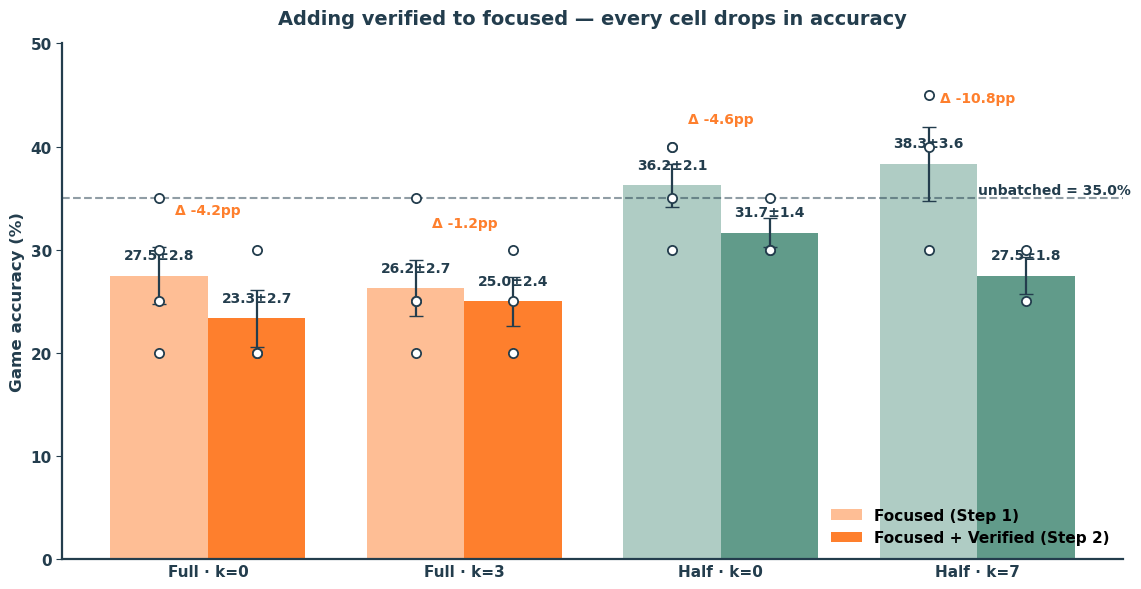

In [19]:
pairs = [
    ('Full · k=0', 'full_focused',      'full_focused_v',     PUMPKIN),
    ('Full · k=3', 'full_focused_k3',   'full_focused_k3_v',  PUMPKIN),
    ('Half · k=0', 'half_focused',      'half_focused_v',     SEAGRASS),
    ('Half · k=7', 'half_focused_k7',   'half_focused_k7_v',  SEAGRASS),
]

fig, ax = plt.subplots(figsize=(11.5, 6))
x = np.arange(len(pairs))
w = 0.38

# focused (Step 1) — lighter
for i, (name, k1, k2, c) in enumerate(pairs):
    s1 = cells[k1]; s2 = cells[k2]
    if s1:
        ax.bar(i - w/2, s1['game_mean'], w, color=c, alpha=0.50,
               edgecolor='none', yerr=s1['game_se'], capsize=5,
               error_kw={'elinewidth': 1.6, 'ecolor': CHARCOAL},
               label='Focused (Step 1)' if i == 0 else None)
        ax.scatter([i - w/2]*len(s1['game_runs']), s1['game_runs'],
                   color='white', edgecolor=CHARCOAL, linewidth=1.3, s=44, zorder=4)
        ax.text(i - w/2, s1['game_mean'] + 1.6,
                f'{s1["game_mean"]:.1f}±{s1["game_se"]:.1f}', ha='center',
                fontsize=10, color=CHARCOAL, fontweight='bold')
    if s2:
        ax.bar(i + w/2, s2['game_mean'], w, color=c,
               edgecolor='none', yerr=s2['game_se'], capsize=5,
               error_kw={'elinewidth': 1.6, 'ecolor': CHARCOAL},
               label='Focused + Verified (Step 2)' if i == 0 else None)
        ax.scatter([i + w/2]*len(s2['game_runs']), s2['game_runs'],
                   color='white', edgecolor=CHARCOAL, linewidth=1.3, s=44, zorder=4)
        ax.text(i + w/2, s2['game_mean'] + 1.6,
                f'{s2["game_mean"]:.1f}±{s2["game_se"]:.1f}', ha='center',
                fontsize=10, color=CHARCOAL, fontweight='bold')
        # Δ arrow annotation
        delta = s2['game_mean'] - s1['game_mean']
        ax.annotate(f'Δ {delta:+.1f}pp',
                    xy=(i, max(s1['game_mean'], s2['game_mean']) + 6),
                    ha='center', fontsize=10,
                    color=PUMPKIN if delta < 0 else SEAGRASS,
                    fontweight='bold')

ax.axhline(cells['unbatched']['game_mean'], color=CHARCOAL, linestyle='--',
           linewidth=1.5, alpha=0.5, zorder=1)
ax.text(len(pairs) - 0.4, cells['unbatched']['game_mean'] + 0.4,
        f'unbatched = {cells["unbatched"]["game_mean"]:.1f}%',
        ha='right', color=CHARCOAL, fontsize=10, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels([n for n, *_ in pairs])
ax.set_ylabel('Game accuracy (%)')
ax.set_ylim(0, 50)
ax.set_title('Adding verified to focused — every cell drops in accuracy', pad=14)
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## Variance comparison: SE before vs after verified

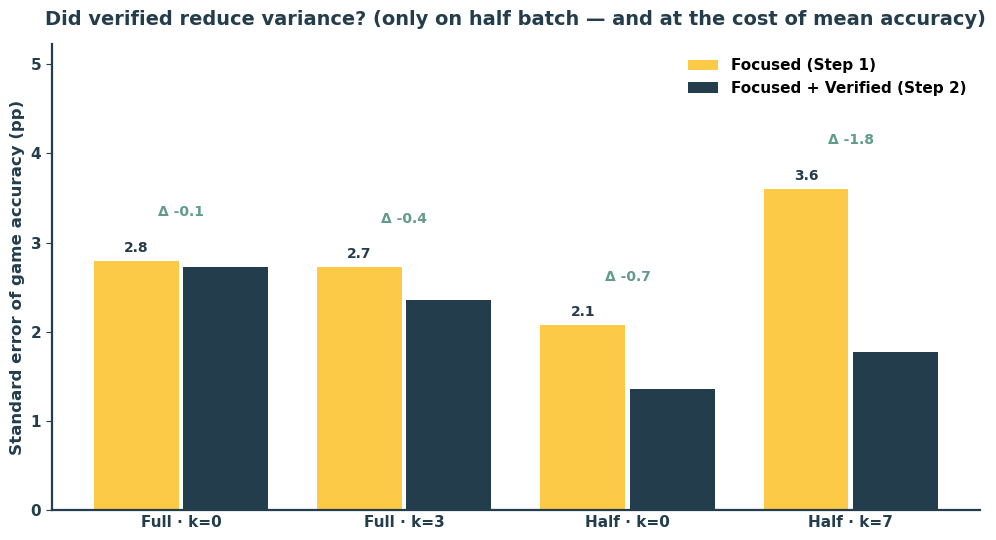

In [20]:
fig, ax = plt.subplots(figsize=(10, 5.5))
x = np.arange(len(pairs))
ses_before = [cells[k1]['game_se'] for _, k1, _, _ in pairs]
ses_after  = [cells[k2]['game_se'] for _, _, k2, _ in pairs]

ax.bar(x - 0.20, ses_before, 0.38, color=GOLDEN,  label='Focused (Step 1)',          edgecolor='none')
ax.bar(x + 0.20, ses_after,  0.38, color=CHARCOAL, label='Focused + Verified (Step 2)', edgecolor='none')
for xi, b, a in zip(x, ses_before, ses_after):
    ax.text(xi - 0.20, b + 0.1, f'{b:.1f}', ha='center', fontsize=10,
            color=CHARCOAL, fontweight='bold')
    ax.text(xi + 0.20, a + 0.1, f'{a:.1f}', ha='center', fontsize=10,
            color='white' if a > 0.5 else CHARCOAL, fontweight='bold')
    delta = a - b
    ax.text(xi, max(a, b) + 0.5, f'Δ {delta:+.1f}', ha='center', fontsize=10,
            color=SEAGRASS if delta < 0 else PUMPKIN, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels([n for n, *_ in pairs])
ax.set_ylabel('Standard error of game accuracy (pp)')
ax.set_title('Did verified reduce variance? (only on half batch — and at the cost of mean accuracy)', pad=14)
ax.set_ylim(0, max(ses_before + ses_after) * 1.45)
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

## 5. Cost / accuracy

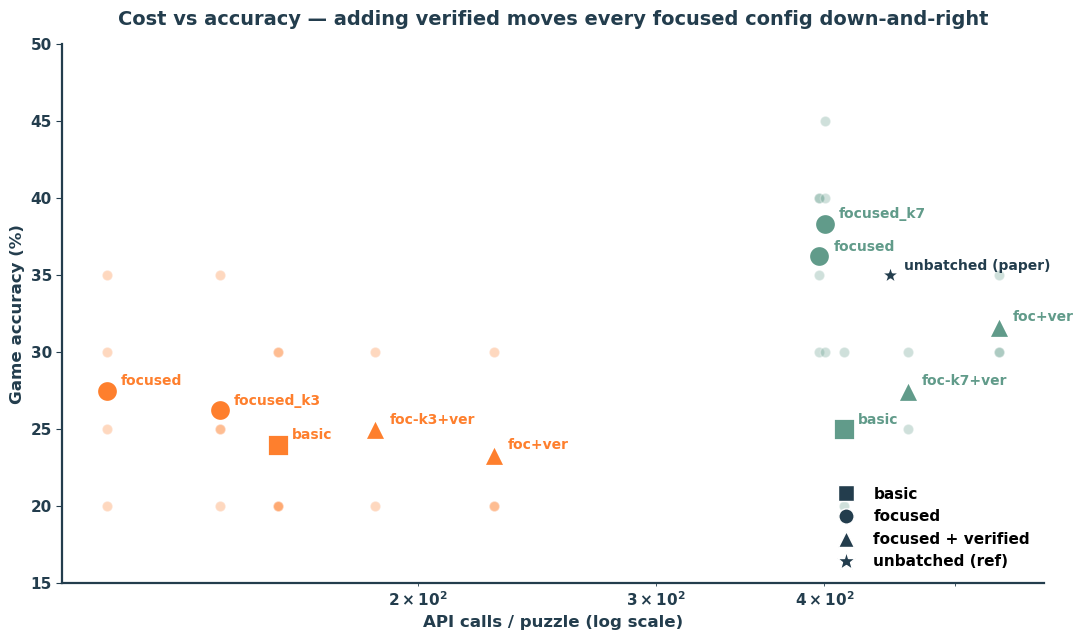

In [21]:
marker_for = {'focused': 'o', 'focused_v': '^'}

fig, ax = plt.subplots(figsize=(11, 6.5))
items = [
    ('full_focused',        PUMPKIN, 'o'),
    ('full_focused_k3',     PUMPKIN, 'o'),
    ('full_focused_v',      PUMPKIN, '^'),
    ('full_focused_k3_v',   PUMPKIN, '^'),
    ('half_focused',        SEAGRASS,'o'),
    ('half_focused_k7',     SEAGRASS,'o'),
    ('half_focused_v',      SEAGRASS,'^'),
    ('half_focused_k7_v',   SEAGRASS,'^'),
    ('full_basic',          PUMPKIN, 's'),
    ('half_basic',          SEAGRASS,'s'),
]
for key, color, marker in items:
    c = cells.get(key)
    if c is None: continue
    ax.scatter([c['calls_mean']]*len(c['game_runs']), c['game_runs'],
               s=55, color=color, alpha=0.30, edgecolor='white', zorder=2)
    ax.scatter(c['calls_mean'], c['game_mean'], s=240, color=color,
               marker=marker, edgecolor='white', linewidth=2.0, zorder=4)
    short = key.replace('focused_v', 'foc+ver').replace('focused_k7_v', 'foc-k7+ver').replace('focused_k3_v', 'foc-k3+ver')
    short = short.replace('full_', '').replace('half_', '')
    ax.annotate(short, (c['calls_mean'], c['game_mean']),
                xytext=(10, 4), textcoords='offset points',
                fontsize=10, color=color, fontweight='bold')

u = cells['unbatched']
ax.scatter(u['calls_mean'], u['game_mean'], s=260, color=CHARCOAL, marker='*',
           edgecolor='white', linewidth=2.0, zorder=4)
ax.annotate('unbatched (paper)', (u['calls_mean'], u['game_mean']),
            xytext=(10, 4), textcoords='offset points',
            fontsize=10, color=CHARCOAL, fontweight='bold')

legend_handles = [
    Line2D([0],[0], marker='s', color='w', markerfacecolor=CHARCOAL, markersize=11, label='basic'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=CHARCOAL, markersize=11, label='focused'),
    Line2D([0],[0], marker='^', color='w', markerfacecolor=CHARCOAL, markersize=11, label='focused + verified'),
    Line2D([0],[0], marker='*', color='w', markerfacecolor=CHARCOAL, markersize=14, label='unbatched (ref)'),
]
ax.legend(handles=legend_handles, loc='lower right')
ax.set_xscale('log')
ax.set_xlabel('API calls / puzzle (log scale)')
ax.set_ylabel('Game accuracy (%)')
ax.set_title('Cost vs accuracy — adding verified moves every focused config down-and-right', pad=14)
ax.set_ylim(15, 50)
fig.tight_layout()
plt.show()

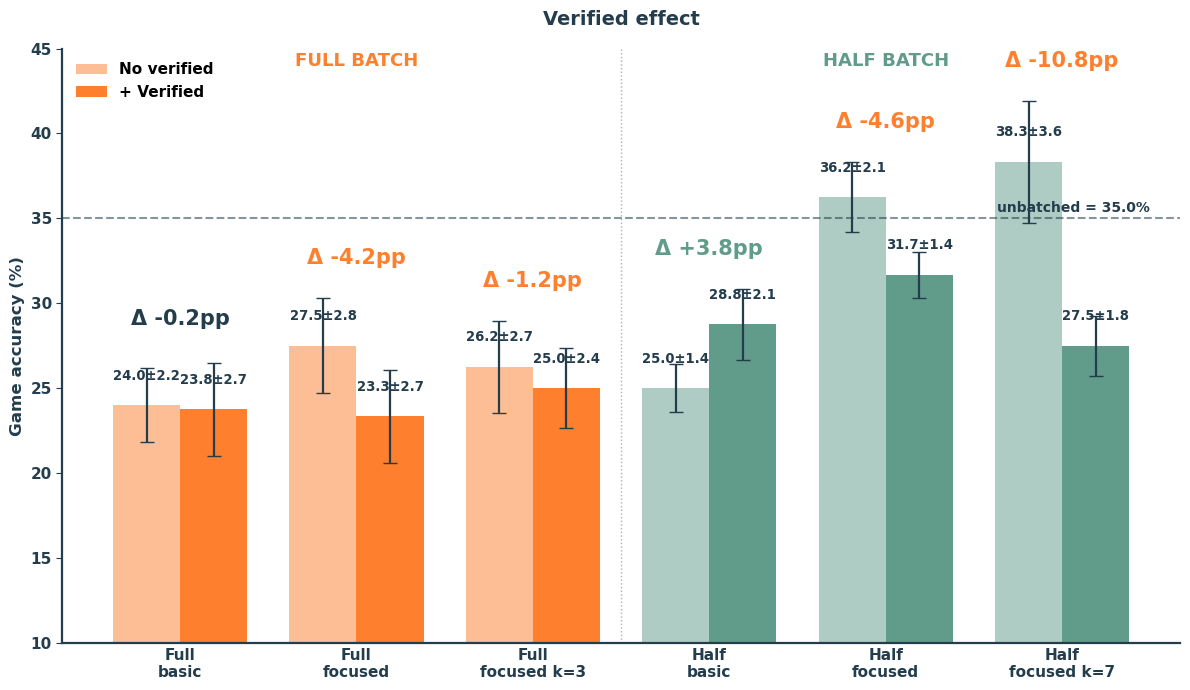

In [68]:
basic_vs_focused_pairs = [
    # FULL BATCH block
    ('Full\nbasic',         'full_basic',       'full_verified',            PUMPKIN),
    ('Full\nfocused',       'full_focused',     'full_focused_v',           PUMPKIN),
    ('Full\nfocused k=3',   'full_focused_k3',  'full_focused_k3_v',        PUMPKIN),
    # HALF BATCH block
    ('Half\nbasic',         'half_basic',       'half_verified',            SEAGRASS),
    ('Half\nfocused',       'half_focused',     'half_focused_v',           SEAGRASS),
    ('Half\nfocused k=7',   'half_focused_k7',  'half_focused_k7_v',        SEAGRASS),
]

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(basic_vs_focused_pairs))
w = 0.38

for i, (name, k1, k2, c) in enumerate(basic_vs_focused_pairs):
    s1 = cells[k1]; s2 = cells[k2]
    # No-verified bar (lighter alpha)
    ax.bar(i - w/2, s1['game_mean'], w, color=c, alpha=0.50, edgecolor='none',
           yerr=s1['game_se'], capsize=5,
           error_kw={'elinewidth': 1.6, 'ecolor': CHARCOAL},
           label='No verified' if i == 0 else None)
#     ax.scatter([i - w/2]*len(s1['game_runs']), s1['game_runs'],
#                color='white', edgecolor=CHARCOAL, linewidth=1.3, s=42, zorder=4)
    ax.text(i - w/2, s1['game_mean'] + 1.5,
            f'{s1["game_mean"]:.1f}±{s1["game_se"]:.1f}',
            ha='center', fontsize=9.5, color=CHARCOAL, fontweight='bold')

    # +Verified bar (full saturation)
    ax.bar(i + w/2, s2['game_mean'], w, color=c, edgecolor='none',
           yerr=s2['game_se'], capsize=5,
           error_kw={'elinewidth': 1.6, 'ecolor': CHARCOAL},
           label='+ Verified' if i == 0 else None)
#     ax.scatter([i + w/2]*len(s2['game_runs']), s2['game_runs'],
#                color='white', edgecolor=CHARCOAL, linewidth=1.3, s=42, zorder=4)
    ax.text(i + w/2, s2['game_mean'] + 1.5,
            f'{s2["game_mean"]:.1f}±{s2["game_se"]:.1f}',
            ha='center', fontsize=9.5, color=CHARCOAL, fontweight='bold')

    # Δ above the pair
    delta = s2['game_mean'] - s1['game_mean']
    delta_color = SEAGRASS if delta > 0.5 else PUMPKIN if delta < -0.5 else CHARCOAL
    ymax_pair = max(s1['game_mean'], s2['game_mean']) + max(s1['game_se'], s2['game_se'])
    ax.annotate(f'Δ {delta:+.1f}pp',
                xy=(i, ymax_pair + 2),
                ha='center', fontsize=15, color=delta_color, fontweight='bold')

# Reference: unbatched
u = cells['unbatched']
ax.axhline(u['game_mean'], color=CHARCOAL, linestyle='--', linewidth=1.5, alpha=0.55, zorder=1)
ax.text(len(basic_vs_focused_pairs) - 0.5, u['game_mean'] + 0.4,
        f'unbatched = {u["game_mean"]:.1f}%',
        ha='right', color=CHARCOAL, fontsize=10, fontweight='bold')

# Visual separator + group labels between the FULL and HALF blocks
ax.axvline(2.5, color=CHARCOAL, linestyle=':', linewidth=1.0, alpha=0.4)
ax.text(1, 44, 'FULL BATCH', ha='center', fontsize=13, color=PUMPKIN, fontweight='bold')
ax.text(4, 44, 'HALF BATCH', ha='center', fontsize=13, color=SEAGRASS, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([n for n, *_ in basic_vs_focused_pairs])
ax.set_ylabel('Game accuracy (%)')
ax.set_ylim(10, 45)
ax.set_title('Verified effect',
             pad=17)
ax.legend(loc='upper left', ncol=1)
fig.tight_layout()
plt.show()